In [1]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import glob
import os
import shutil

In [117]:
# # Anatomical Data / Segmentation (SOURCE)
# allAnat = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalData"
# oneAnat = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalData\\001.dcm"

# # ProbesEye Data
# allProbes = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalProbesEye"
# oneProbes = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\anatomicalProbesEye\\coarse.S2.dcm"

# # Temperature Data (TARGET)
# allTemp = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\temperatureDataS2"
# oneTemp = "E:\Documents\MTLE\LP-0008\LP-0008-01-01-01\\temperatureDataS2\\071.S2.dcm"

In [554]:
# Anatomical Data / Segmentation (SOURCE)
allAnat = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalSeg"
oneAnat = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalSeg\\100.dcm"

# ProbesEye Data
allProbes = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye"
oneProbes = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalProbesEye\\coarse.S2.dcm"

# Temperature Data (TARGET)
allTemp = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\temperatureDataS2"
oneTemp = "E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\temperatureDataS2\\071.S2.dcm"


In [555]:
# Load in Anatomical Data
# A file name that belongs to the series we want to read

# Read the file's meta-information without reading bulk pixel data
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(allAnat)
reader.SetFileNames(dicom_names)
data_img = reader.Execute()

print(data_img.GetSize())
data_img.GetSpacing()


(256, 256, 160)


(1.0, 1.0, 0.999999999999991)

In [556]:
# Load in Temperature Data
# A file name that belongs to the series we want to read

# Read the file's meta-information without reading bulk pixel data
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(allTemp)
reader.SetFileNames(dicom_names)
temp_img = reader.Execute()

print(temp_img.GetSize())
temp_img.GetSpacing()


(128, 128, 79)


(2.0, 2.0, 1.0)

In [557]:
# Load in ProbesEye Data
# A file name that belongs to the series we want to read

# Read the file's meta-information without reading bulk pixel data
reader = sitk.ImageSeriesReader()
dicom_names = reader.GetGDCMSeriesFileNames(allProbes)
reader.SetFileNames(dicom_names)
probes_img = reader.Execute()

print(probes_img.GetSize())
probes_img.GetSpacing()

(128, 128, 3)


(2.0, 2.0, 5.249999738254797)

In [558]:
# real_seg = pydicom.dcmread(oneAnat)

# seg_array = real_seg.pixel_array

# plt.figure(figsize=(12, 6))  # Set the figure size
# plt.subplot(1, 3, 1)
# plt.imshow(seg_array, cmap= 'gray')
# plt.title("Resampled Segmentation from anatomicalData")
# plt.axis('off')

In [559]:
# reference_center = np.array(
#     temp_img.TransformContinuousIndexToPhysicalPoint(np.array(temp_img.GetSize()) / 2.0))

# dimension = temp_img.GetDimension()
# transform = sitk.AffineTransform(dimension) # use affine transform with 3 dimensions
# transform.SetMatrix(data_img.GetDirection()) # set the cosine direction matrix
# print(data_img.GetDirection())
# transform.SetCenter(reference_center)

# centered_transform = sitk.Transform(transform)

#%% set all  output image parameters: origin, spacing, direction, starting index, and size.
resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(temp_img)
resampler.SetDefaultPixelValue(data_img.GetPixelIDValue())
resampler.SetSize((128, 128, 1))
resampler.SetOutputSpacing((2.0,2.0,1.0))
resampler.SetOutputOrigin(temp_img.GetOrigin())
resampler.SetOutputDirection(temp_img.GetDirection())
resampler.SetInterpolator(sitk.sitkLinear)



resampled_img = resampler.Execute(data_img)

# resampled_image = sitk.Resample(logo, output_size, euler2d, sitk.sitkLinear, output_origin, output_spacing, output_direction)


In [560]:
print("temp_img")
print("data_img")
print("probes_img")
print("resampled_img")
print()
print("Sizes:")
print(temp_img.GetSize())
print(data_img.GetSize())
print(probes_img.GetSize())
print(resampled_img.GetSize())

print("Direction:")
print(temp_img.GetDirection())
print(data_img.GetDirection())
print(probes_img.GetDirection())
print(resampled_img.GetDirection())

print("Origin:")
print(temp_img.GetOrigin())
print(data_img.GetOrigin())
print(probes_img.GetOrigin())
print(resampled_img.GetOrigin())


print("Spacing:")
print(temp_img.GetSpacing())
print(data_img.GetSpacing())
print(probes_img.GetSpacing())
print(resampled_img.GetSpacing())

temp_img
data_img
probes_img
resampled_img

Sizes:
(128, 128, 79)
(256, 256, 160)
(128, 128, 3)
(128, 128, 1)
Direction:
(0.9572716758259795, 0.18382109648024186, 0.2232504045911724, -0.2891901427456346, 0.6084803201578172, 0.738999838511078, 2.829528291960375e-07, -0.7719854302183697, 0.6356402249153826)
(1.0, 2.0510300097000022e-10, -2.096623381321676e-16, -1.905679552919864e-10, 0.9291325668993408, -0.36974676892035435, -7.58359771004195e-11, 0.36974676892035435, 0.9291325668993408)
(0.9572716758259809, 0.1838210964802344, 0.22325040459117335, -0.2891901427456305, 0.6084803201578116, 0.7389998385110849, 2.8295282566980454e-07, -0.7719854302183767, 0.6356402249153749)
(0.9572716758259795, 0.18382109648024186, 0.2232504045911724, -0.2891901427456346, 0.6084803201578172, 0.738999838511078, 2.829528291960375e-07, -0.7719854302183697, 0.6356402249153826)
Origin:
(-130.25993347168, -24.56925201416, 125.514106750488)
(-137.08100891113, -80.229301452637, -70.251022338867)
(-131.43200683594,

In [570]:
ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\temperatureDataS2\\002.S2.dcm")
# ds = pydicom.dcmread("E:\Documents\MTLE\LP-0001\LP-0001-01-01-01\\anatomicalData\\010.dcm")
laser_point = np.array([14.80606195, 15.85856865, 27.5923181, 1])
Sxyz = ds[0x0020,0x0032].value
Xxyz = ds[0x0020,0x0037].value
Yxyz = ds[0x0020,0x0037].value

Xxyz = np.array(Xxyz[0:3])
Yxyz = np.array(Yxyz[3:6])

itri = ds[0x0028,0x0030].value
jtri = ds[0x0028,0x0030].value

print("point:", laser_point[0:3])
print("Sxyz:",Sxyz)
print("Xxyz:",Xxyz)
print("Yxyz:",Yxyz)
print("itri:",2)

# np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]], [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]], ])

trans = np.array([[Xxyz[0]*2, Yxyz[0]*2, 0, Sxyz[0]],
                  [Xxyz[1]*2, Yxyz[1]*2, 0, Sxyz[1]],
                  [Xxyz[2]*2, Yxyz[2]*2, 0, Sxyz[2]],
                  [0, 0, 0, 1]]  )


trans_mat = np.linalg.pinv(trans)
new_laser = np.dot(trans_mat,laser_point)

new_laser = new_laser[:-1]
print(new_laser)





# writer = sitk.ImageFileWriter()
# writer.SetFileName(outputImageFileName)
# writer.Execute(seg_img)

point: [14.80606195 15.85856865 27.5923181 ]
Sxyz: [-130.25993347168, -24.56925201416, 125.514106750488]
Xxyz: [ 9.57271993e-01 -2.89189994e-01 -1.04475995e-09]
Yxyz: [ 0.18382099  0.60847998 -0.77198499]
itri: 2
[63.62268496 63.46992067  0.        ]


In [562]:
# def create_normal_plane(second_slice_path):
#     ds = pydicom.dcmread(second_slice_path)
#     #extract image orientation
#     Image_orientation_1 = ds[0x0020,0x0037].value
#     lst_image_orientation = list(Image_orientation_1)
#     #make it as two vectors for rows and columns
#     row_vector = np.array(lst_image_orientation[0:3])
#     print("row_vector:", row_vector)
#     column_vector = np.array(lst_image_orientation[3:6])
#     print("column_vector: ", column_vector)

#     row_vector = np.append(row_vector, 1)
#     column_vector = np.append(column_vector, 1)
#     row_vector = np.dot(trans_mat,row_vector)
#     column_vector = np.dot(trans_mat,column_vector)
#     row_vector = np.delete(row_vector, 3)
#     column_vector = np.delete(column_vector, 3)

#     #normal plane computed as the cross-product of the row and column vectors
#     normal_plane = np.cross(row_vector,column_vector)
#     print("normal_plane: ", normal_plane)
#     return normal_plane

# # second_slice = r"E:\MRgLITT Data\new data\2021-12-21\MTLE-2.2DTP\LP-0001\LP-0001-01-01-01\anatomicalProbesEye\coarse.S2.dcm"
# second_slice = r"E:\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\temperatureDataS2\\002.S2.dcm"
# normal_plane = create_normal_plane(second_slice)

In [563]:
# def extract_plane_point(second_slice_path):
    
#     ds = pydicom.dcmread(second_slice_path)

#     #extract image position
#     Image_Position_1 = ds[0x0020,0x0032].value
#     lst_image_position=[]
#     lst_image_position.append(float(Image_Position_1[0]))
#     lst_image_position.append(float(Image_Position_1[1]))
#     lst_image_position.append(float(Image_Position_1[2]))
    
#     lst_image_position = np.array(lst_image_position)
#     lst_image_position = np.append(lst_image_position, 1)
#     lst_image_position = np.dot(trans_mat,lst_image_position)
#     lst_image_position = lst_image_position[:-1]
#     return lst_image_position

# lst_image_position = extract_plane_point("E:\Documents\\MTLE\\LP-0001\\LP-0001-01-01-01\\temperatureDataS2\\002.S2.dcm")

# print(lst_image_position)


In [564]:
# def project(plane_point, plane_normal, point):
   
#     v = point - plane_point
#     dist = np.dot(v, plane_normal)
#     projected_point = point - dist * plane_normal
#     return projected_point

# laser_onplane_1 = project(lst_image_position, normal_plane, new_laser)
# print("Before intersection: ", new_laser)
# print("Laser intersection 1: ", laser_onplane_1)

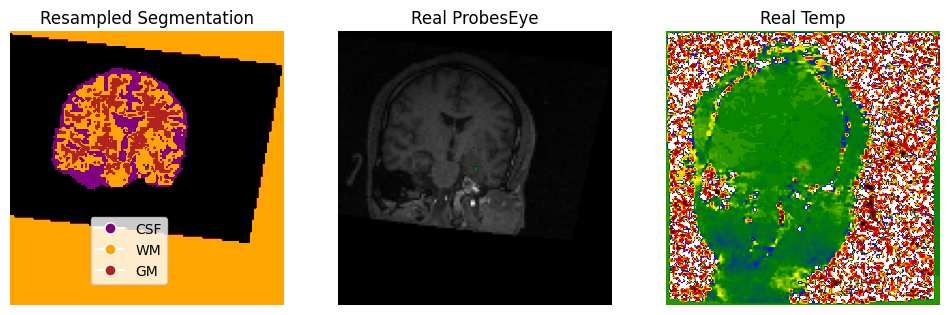

In [571]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
colors_1=["white", "darkmagenta","blue","green","yellow","orange","red", "black"]
nodes_1 = [0.0, 0.04, 0.078, 0.14, 0.17, 0.23, 0.34, 1.0]
Monteris_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(nodes_1, colors_1)))
# colors = ['black', 'purple', 'orange', 'firebrick']
# values = [0, 1/3, 2/3, 1]
# labels = ['CSF', 'GM', 'WM']
# custom_colormap = LinearSegmentedColormap.from_list("mycmap", list(zip(values, colors)))

colors = ['black', 'purple', 'orange', 'firebrick']
integer_values = [0, 1, 2, 3]
labels = ['CSF', 'WM', 'GM']

# Create the custom colormap
custom_colormap = ListedColormap(colors)

import pydicom



slice_image = resampled_img[:, :,0]
slice_array = sitk.GetArrayFromImage(slice_image)

real_probes = pydicom.dcmread(oneProbes)
real_temp = pydicom.dcmread(oneTemp)
probes_array = real_probes.pixel_array
temp_array = real_temp.pixel_array

plt.figure(figsize=(12, 6))  # Set the figure size

plt.subplot(1, 3, 1)
plt.imshow(slice_array, cmap=custom_colormap, vmin=0, vmax=max(integer_values))
plt.title("Resampled Segmentation")
plt.axis('off')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=label)
                    for label, color in zip(labels, colors[1:])]
plt.legend(handles=legend_elements, loc='center right', bbox_to_anchor = (0.6,0.2))
plt.scatter(new_laser[0], new_laser[1], color='green', s=1)

plt.subplot(1, 3, 2)
plt.imshow(probes_array, cmap='gray')
plt.title("Real ProbesEye")
plt.axis('off')
plt.scatter(new_laser[0], new_laser[1], color='green', s=1)

plt.subplot(1, 3, 3)
plt.imshow(temp_array, cmap=Monteris_cmap,vmin=0, vmax=255)
plt.title("Real Temp")
plt.axis('off')
plt.scatter(new_laser[0], new_laser[1], color='red', s=1)


plt.show()

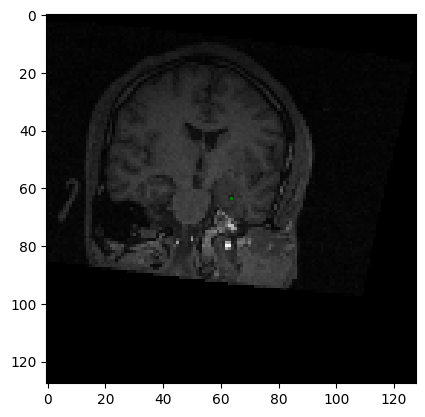

In [566]:

plt.imshow(probes_array, cmap='gray', interpolation='none')
# plt.imshow(slice_array, cmap=custom_colormap, interpolation='none')
plt.scatter(new_laser[0], new_laser[1], color='green', s=2)
# plt.scatter(64, 64, color='green', s=2)


# writer = sitk.ImageFileWriter()
# writer.SetFileName(outputImageFileName)
# writer.Execute(seg_img)

In [535]:
import math

segmentation_full = slice_array
print(segmentation_full)
print(new_laser)


left = (new_laser[0] - 25.5)
right = (new_laser[0] + 25.5)
top = (new_laser[1] + 25.5)
bottom = (new_laser[1] - 25.5)


# Account for even center so that laser is always in the middle pixel
if (left % 2) == 0 or(right % 2) == 0:
    left -= 1
    right += 1
if (top % 2) == 0 or(bottom % 2) == 0:
    top += 1
    bottom -= 1

print("Left, Right, Top, Bottom:", left,right,bottom,top)

left = math.floor(left)
right = math.floor(right)
top = math.floor(top)
bottom = math.floor(bottom)

# Define the region to crop
region = [left, top, 0]  # Start index (left, top) at slice 0
size = [right - left, bottom - top, 0]  # Size of the cropped region

# crop the image
segmentation_cropped = segmentation_full[left:right, bottom:top]

np.unique(segmentation_cropped)

# cropped_image = image.crop((left, upper, right, lower)

[[2 2 2 ... 2 2 2]
 [0 2 2 ... 2 2 2]
 [0 0 0 ... 2 2 2]
 ...
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]]
[63.62268496 63.46992067  0.        ]
Left, Right, Top, Bottom: 38.122684962681014 89.122684962681 37.96992067271631 88.96992067271631


array([0, 1, 2, 3], dtype=int16)

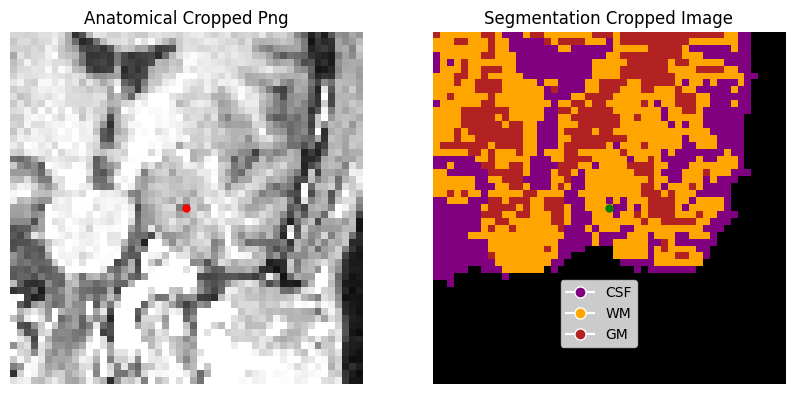

In [568]:
plt.figure(figsize=(10, 5))  # Set the figure size
plt.subplot(1, 2, 1)
dir = "E:\Documents\MRgLITT\data\\500J\original\\anatomicalProbesEye\LP-0001-01-01-01-S2Cropped.png"
anatCropped= Image.open(dir)



plt.subplot(1, 2, 1)
plt.imshow(anatCropped)
plt.title('Anatomical Cropped Png')
plt.axis('off')
plt.scatter(25, 25, color='red', s=25)

# plt.show()

# plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2)
plt.imshow(segmentation_cropped,cmap=custom_colormap, vmin=0, vmax=max(integer_values))
plt.title('Segmentation Cropped Image')
plt.axis('off')  
plt.legend(handles=legend_elements, loc='center right', bbox_to_anchor = (0.6,0.2))
plt.scatter(25, 25, color='green', s=25)

plt.show()


In [527]:
def pixel2pixel_difference_visualization(real_temp, predicted_temp):
    real_temp_arr = np.array(real_temp)
#     print("real_temp_arr", type(real_temp_arr))
    predicted_temp_arr = np.array(predicted_temp)
#     print("predicted_temp_arr", type(predicted_temp_arr))
    
    diff = predicted_temp_arr.astype(float)-real_temp_arr.astype(float)
    min_ = np.min(diff)
    max_ = np.max(diff)
    return diff, min_, max_
                        

(128, 128)

(128, 128)

In [563]:
np.array_equal(slice_array, probes_array)

False

In [521]:
diff = [slice_array == probes_array]

In [524]:
len(probes_array)

128

In [526]:
len(diff)

1